# 图像增广
:label:`sec_image_augmentation`

 :numref:`sec_alexnet`提到过大型数据集是成功应用深度神经网络的先决条件。
图像增广在对训练图像进行一系列的随机变化之后，生成相似但不同的训练样本，从而扩大了训练集的规模。
此外，应用图像增广的原因是，随机改变训练样本可以减少模型对某些属性的依赖，从而提高模型的泛化能力。
例如，我们可以以不同的方式裁剪图像，使感兴趣的对象出现在不同的位置，减少模型对于对象出现位置的依赖。
我们还可以调整亮度、颜色等因素来降低模型对颜色的敏感度。
可以说，图像增广技术对于AlexNet的成功是必不可少的。本节将讨论这项广泛应用于计算机视觉的技术。


In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

## 常用的图像增广方法

在对常用图像增广方法的探索时，我们将使用下面这个尺寸为$400\times 500$的图像作为示例。


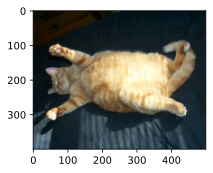

In [2]:
d2l.set_figsize()  # 设置图像显示窗口的尺寸
img = d2l.Image.open('../img/cat1.jpg')
d2l.plt.imshow(img);

大多数图像增广方法都具有一定的随机性。为了便于观察图像增广的效果，我们下面定义辅助函数`apply`。
此函数在输入图像`img`上多次运行图像增广方法`aug`并显示所有结果。


In [3]:
# 这是一个图像增广展示函数，目的是用来“多次对同一张图片应用随机的增广方法”，并把结果画出来，方便观察增广的“多样性”。
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    # img：要增广的原图（就是上面的猫图）
    # aug：传入的图像增广方法，比如 RandomFlip、ColorJitter
    # num_rows 和 num_cols：展示的图像排布
    # scale：每张图的缩放系数

    # 用一个列表生成式对同一张 img 重复增广多次，每次都是新的随机变换。
    Y = [aug(img) for _ in range(num_rows * num_cols)]

    # 将生成的增广图像列表 Y 以网格形式画出来，方便观察图像增广效果是否自然、有效。
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

### 翻转和裁剪

[**左右翻转图像**]通常不会改变对象的类别。这是最早且最广泛使用的图像增广方法之一。
接下来，我们使用`transforms`模块来创建`RandomFlipLeftRight`实例，这样就各有50%的几率使图像向左或向右翻转。


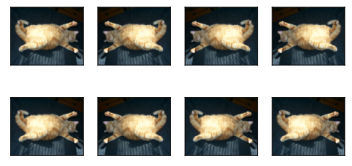

In [4]:
apply(img, torchvision.transforms.RandomHorizontalFlip())  # 传入img和aug

[**上下翻转图像**]不如左右图像翻转那样常用。但是，至少对于这个示例图像，上下翻转不会妨碍识别。接下来，我们创建一个`RandomFlipTopBottom`实例，使图像各有50%的几率向上或向下翻转。


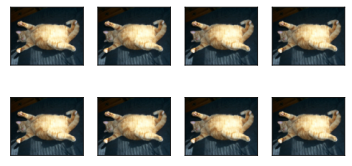

In [5]:
apply(img, torchvision.transforms.RandomVerticalFlip())

在我们使用的示例图像中，猫位于图像的中间，但并非所有图像都是这样。
在 :numref:`sec_pooling`中，我们解释了汇聚层可以降低卷积层对目标位置的敏感性。
另外，我们可以通过对图像进行随机裁剪，使物体以不同的比例出现在图像的不同位置。
这也可以降低模型对目标位置的敏感性。

下面的代码将[**随机裁剪**]一个面积为原始面积10%到100%的区域，该区域的宽高比从0.5～2之间随机取值。
然后，区域的宽度和高度都被缩放到200像素。
在本节中（除非另有说明），$a$和$b$之间的随机数指的是在区间$[a, b]$中通过均匀采样获得的连续值。


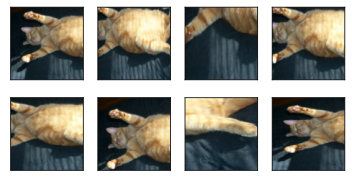

In [6]:
# 定义增广操作
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
# 这个操作可以分为两个步骤：
#     1. 随机裁剪一块区域：
#         面积范围：原图面积的 10% 到 100% 之间（由 scale=(0.1, 1) 控制）
#         宽高比范围：0.5 到 2（由 ratio=(0.5, 2) 控制）
#         📌 举例：猫的肚子、腿、脸被单独裁出来一块
#     2. 将这块裁剪的图缩放到目标大小：200 x 200 像素
#         ⚠️ 即裁剪 + 缩放 是一次完成的。

# 应用增广并展示
apply(img, shape_aug)
# 注意：虽然 RandomResizedCrop 中的 ratio=(0.5, 2) 表示裁剪区域的宽高比是随机变化的，
# 但由于该操作会在裁剪后将图像 resize 成固定大小 (200, 200)，
# 所以最终显示出来的图像看起来都是一样的方形。
# 实际裁剪区域的原始宽高比在不同样本中是不同的，只是被统一缩放显示了。

### 改变颜色

另一种增广方法是改变颜色。
我们可以改变图像颜色的四个方面：亮度、对比度、饱和度和色调。
在下面的示例中，我们[**随机更改图像的亮度**]，随机值为原始图像的50%（$1-0.5$）到150%（$1+0.5$）之间。


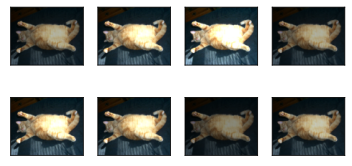

In [7]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))
    # （亮度、对比度、饱和度、色调）

同样，我们可以[**随机更改图像的色调**]。


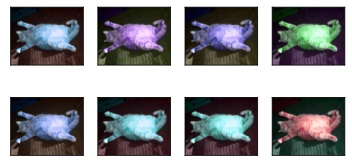

In [8]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

我们还可以创建一个`RandomColorJitter`实例，并设置如何同时[**随机更改图像的亮度（`brightness`）、对比度（`contrast`）、饱和度（`saturation`）和色调（`hue`）**]。


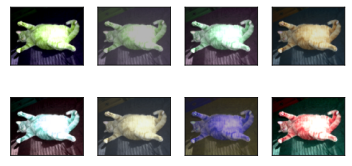

In [9]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

### [**结合多种图像增广方法**]

在实践中，我们将结合多种图像增广方法。比如，我们可以通过使用一个`Compose`实例来综合上面定义的不同的图像增广方法，并将它们应用到每个图像。


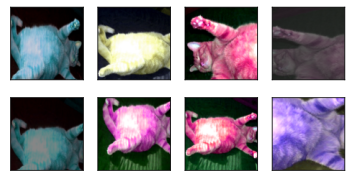

In [10]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])  # 传入了左右翻转，颜色变化，图片裁剪的增广操作
apply(img, augs)

## [**使用图像增广进行训练**]

让我们使用图像增广来训练模型。
这里，我们使用CIFAR-10数据集，而不是我们之前使用的Fashion-MNIST数据集。
这是因为Fashion-MNIST数据集中对象的位置和大小已被规范化，而CIFAR-10数据集中对象的颜色和大小差异更明显。
CIFAR-10数据集中的前32个训练图像如下所示。


Files already downloaded and verified


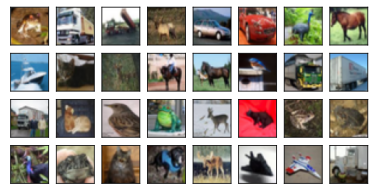

In [11]:
# 下载 CIFAR-10 训练集
all_images = torchvision.datasets.CIFAR10(train=True, root="../data", download=True)
# CIFAR-10 是一个彩色图像分类数据集，包含10类，每张图是 32x32，RGB三通道。

# 展示前32张图像
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8);
# [all_images[i][0] for i in range(32)]：
#     all_images[i] 返回的是 (图像, 标签) 元组
#     [0] 表示只取图像部分
#     所以这行取出前 32 张图像
# show_images(..., 4, 8, scale=0.8)：
#     将图像以 4 行 8 列 排列
#     scale=0.8 控制整体图像显示的缩放程度

为了在预测过程中得到确切的结果，我们通常对训练样本只进行图像增广，且在预测过程中不使用随机操作的图像增广。
在这里，我们[**只使用最简单的随机左右翻转**]。
此外，我们使用`ToTensor`实例将一批图像转换为深度学习框架所要求的格式，即形状为（批量大小，通道数，高度，宽度）的32位浮点数，取值范围为0～1。


In [12]:
# # 下面是课本源码
# train_augs = torchvision.transforms.Compose([
#      torchvision.transforms.RandomHorizontalFlip(),
#      torchvision.transforms.ToTensor()])
# # 使用 Compose([...]) 把多个图像变换组合在一起
# # RandomHorizontalFlip()：以50%概率随机左右翻转图像（仅用于训练阶段）
# # # ToTensor()：把 PIL 图像或 ndarray 转换为 PyTorch 所需的张量（取值范围从 [0,255] → [0,1]，形状变为 （批量大小，通道数，高度，宽度））

# # 由于课本源码只将图片左右翻转了作为增广,我尝试使用上面提到的多种增广方式进行改变
# train_augs = torchvision.transforms.Compose([
#     torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug, torchvision.transforms.ToTensor()])  # 传入了左右翻转，颜色变化，图片裁剪的增广操作

# 由于课本源码只将图片左右翻转了作为增广,我尝试使用上面提到的多种增广方式进行改变
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, torchvision.transforms.ToTensor()])  # 传入了颜色变化的增广操作

test_augs = torchvision.transforms.Compose([
     torchvision.transforms.ToTensor()])
# 测试时不进行任何随机变换，只进行格式转换
# 保证测试数据稳定一致，结果可重复

接下来，我们[**定义一个辅助函数，以便于读取图像和应用图像增广**]。PyTorch数据集提供的`transform`参数应用图像增广来转化图像。有关`DataLoader`的详细介绍，请参阅 :numref:`sec_fashion_mnist`。


In [13]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="../data", train=is_train,
                                           transform=augs, download=True)
    # torchvision.datasets.CIFAR10(...)：
    #     下载并构建数据集对象
    #     transform=augs：指定图像增广或预处理方法
    
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                    shuffle=is_train, num_workers=d2l.get_dataloader_workers())
    # DataLoader(...)：
    #     批量读取图像数据
    #     shuffle=is_train：训练数据打乱，测试数据不打乱
    #     num_workers=...：设置多个线程并行加载数据
    return dataloader

# PyTorch 中常见的数据流动：
# Image Files → Dataset(CIFAR10) → Transform(augs) → DataLoader → 模型训练

### 多GPU训练

我们在CIFAR-10数据集上训练 :numref:`sec_resnet`中的ResNet-18模型。
回想一下 :numref:`sec_multi_gpu_concise`中对多GPU训练的介绍。
接下来，我们[**定义一个函数，使用多GPU对模型进行训练和评估**]。


In [14]:
# 此函数只是：将输入统一放到 devices[0]（主 GPU）
#@save
def train_batch_ch13(net, X, y, loss, trainer, devices):
    """用多GPU进行小批量训练"""
    # net	神经网络模型
    # X, y	输入数据和标签
    # loss	损失函数（如交叉熵）
    # trainer	优化器，如 torch.optim.SGD
    # devices	一个 GPU 列表（如 [gpu0, gpu1]）

     # 1. 将数据发送到主设备（一般是 devices[0]）
    if isinstance(X, list):
        # 微调BERT中所需
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    # 如果 X 是一个列表（如 BERT 输入的多字段），就对其中每个张量都 .to(devices[0])
    # 否则将 X 和 y 直接移动到第一个 GPU 上
    # 这里只支持单卡执行前向传播，暂不分发到多张 GPU 上

    # 2. 正向传播与反向传播
    net.train()  # 启用训练模式
    trainer.zero_grad()  # 清空上一轮的梯度
    pred = net(X)  # 向前传播得到预测值  # 此处 net 是 DataParallel 封装过的模型
    l = loss(pred, y)  # 计算每个样本的损失
    l.sum().backward()  # 求损失的梯度并反向传播

    # 3. 更新参数并计算指标
    trainer.step()  # 根据梯度更新模型参数
    train_loss_sum = l.sum()  # 损失求和，用于可视化
    train_acc_sum = d2l.accuracy(pred, y)  # 计算预测准确度 
    return train_loss_sum, train_acc_sum  # 返回的是本轮训练的总损失和总准确数（通常会累加到 epoch 层面）

这个问题非常关键！它触及到了**多GPU并行训练时梯度的计算和更新机制**。我们来一步一步说明：

---

## ✅ 首先明确一句话：

> **两个 GPU 不是分别处理两个独立 batch，而是“共同处理一个大 batch 的一部分”**，训练时只会 **更新一次参数**。

---

## 🧠 举个例子解释：

假设：

* 你设定的 `batch_size = 128`
* 使用了两个 GPU：`cuda:0` 和 `cuda:1`
* 使用 `nn.DataParallel(net, device_ids=[0, 1])`

### 🔁 PyTorch 的处理流程如下：

#### 1. **数据划分**

* 把 128 个样本划分成两个子 batch：

  * GPU 0：处理前 64 个样本
  * GPU 1：处理后 64 个样本

#### 2. **并行计算**

* 两个 GPU 各自进行：

  * 前向传播：计算 `pred_i = net(X_i)`
  * 损失函数：计算 `loss_i = loss(pred_i, y_i)`
  * 反向传播：计算 `∇loss_i`

#### 3. **主设备（默认 GPU0）负责梯度聚合**

* 收集两个 GPU 上的梯度：

  $$
  \nabla W = \frac{1}{2} (\nabla W_0 + \nabla W_1)
  $$

* 再由主 GPU 执行一次统一的参数更新（`optimizer.step()`）

---

## 📦 总结成一句话：

> **两个 GPU 是同时并行计算一个 batch 的不同部分，训练完这个 batch 后，梯度会被汇总再更新一次模型参数。**

不是每个 GPU 单独处理一个 batch、然后各自更新。

---

## 🧠 与多个 batch 的区别？

| 误解（❌）                                | 实际（✅）                                   |
| ------------------------------------ | --------------------------------------- |
| GPU0 训练 batch 1，GPU1 训练 batch 2，各自更新 | GPU0 和 GPU1 协作处理同一个 batch 的一半，梯度聚合后统一更新 |

如果你真的想要每张 GPU 同时处理一个独立 batch，各自维护自己的模型副本并异步更新参数，那就是**多机/分布式训练（比如 DDP）**，而不是 `DataParallel`。

---

## ✅ 总结：两个 GPU 如何训练并更新？

| 步骤   | 内容                                 |
| ---- | ---------------------------------- |
| 数据划分 | 一个 batch 被分成两部分，分别送到两个 GPU         |
| 并行计算 | 两张卡各自前向 + 反向传播计算局部梯度               |
| 梯度聚合 | 主 GPU 收集所有卡的梯度，进行平均                |
| 参数更新 | 主 GPU 调用一次 `optimizer.step()` 更新参数 |

---

是否需要我画一张示意图或者带你深入对比 `DataParallel` 和 `DistributedDataParallel`？会更清楚一些。


In [15]:
#@save
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus()):
    """用多GPU进行模型训练"""

    # 一、训练准备
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])  # 多GPU的体现
    # Timer()：用于记录训练耗时
    # num_batches：每个 epoch 中的数据批次数
    # Animator：用于实时绘图（训练损失、准确率等）
    # DataParallel(...)：将模型封装为多GPU并行模型
    # .to(devices[0])：模型参数依然保存在主GPU上（PyTorch要求）
        # net 原本是一个普通的模型（如 ResNet18）
        # nn.DataParallel(...) 会把它包裹起来，成为多GPU版本的模型
        # device_ids=devices 指定了你要用的 GPU 列表，例如 [0, 1]
        # .t(devices[0]) 是因为 DataParallel 要求模型参数保存在主 GPU 上（如 GPU0）

    # 二、训练主循环
    for epoch in range(num_epochs):
        # 4个维度：储存训练损失，训练准确度(累加训练正确预测数)，实例数(累加训练样本数)，特点数(累加训练样本数（用于准确率）)
        metric = d2l.Accumulator(4)
        
        for i, (features, labels) in enumerate(train_iter):
            timer.start()

            # 三、小批量训练
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            # 调用之前定义的 train_batch_ch13() 进行一批训练
            # 收集这一批的损失 l、准确数 acc、样本数 labels.shape[0]
            # 将它们累加到 metric 中
            
            timer.stop()

            # 四、可视化中间训练过程（每 1/5 批可视化一次）
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3], None))
            # 这一步是在训练过程中将损失和准确率实时画在图上，便于观察训练进展。

        # 五、测试集评估与可视化
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        # 每轮训练后在验证集上评估准确率
        # 加入可视化曲线中的“test acc”部分

    # 六、打印日志
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')
    # 当前轮的平均损失、训练准确率、测试准确率
    # 每秒处理样本数（即训练速度），用于评估多GPU效率

现在，我们可以[**定义`train_with_data_aug`函数，使用图像增广来训练模型**]。该函数获取所有的GPU，并使用Adam作为训练的优化算法，将图像增广应用于训练集，最后调用刚刚定义的用于训练和评估模型的`train_ch13`函数。


In [16]:
 # ① 准备阶段：设置参数、模型、初始化权重
batch_size, devices, net = 256, d2l.try_all_gpus(), d2l.resnet18(10, 3)
# d2l.resnet18(10, 3)：加载预定义的 ResNet-18 模型
#     10 是类别数（CIFAR-10 有10类）
#     3 是输入通道数（RGB三通道）
# 源码batch_size是256

# 初始化权重
def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:  # 适用于 Linear 和 Conv2d 层
        nn.init.xavier_uniform_(m.weight)  # 对模型中每一层应用权重初始化（Xavier初始化法）

net.apply(init_weights)

 # ② 定义主函数 train_with_data_aug()
# 这是一个封装后的训练函数，你只需传入图像增广和模型，它会完成所有训练工作。
def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    # 加载数据（带图像增广）
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    # train_augs：对训练集应用图像增广（如随机左右翻转）
    # test_augs：对测试集仅做 ToTensor() 变换

    # 定义损失函数、优化器
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    # 使用交叉熵损失，不进行批量平均（方便后续自己手动统计）
    # 使用 Adam 优化器（相对鲁棒）

    # 启动训练
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)
    # 调用我们前面已经定义好的多GPU训练主函数 train_ch13
    # 使用刚设置好的优化器、损失函数、数据迭代器
    # 训练 10 个 epoch

让我们使用基于随机左右翻转的图像增广来[**训练模型**]。


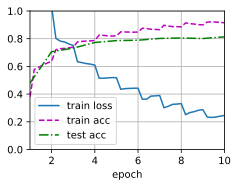

In [17]:
train_with_data_aug(train_augs, test_augs, net)

## 小结

* 图像增广基于现有的训练数据生成随机图像，来提高模型的泛化能力。
* 为了在预测过程中得到确切的结果，我们通常对训练样本只进行图像增广，而在预测过程中不使用带随机操作的图像增广。
* 深度学习框架提供了许多不同的图像增广方法，这些方法可以被同时应用。

## 练习

1. 在不使用图像增广的情况下训练模型：`train_with_data_aug(no_aug, no_aug)`。比较使用和不使用图像增广的训练结果和测试精度。这个对比实验能支持图像增广可以减轻过拟合的论点吗？为什么？
2. 在基于CIFAR-10数据集的模型训练中结合多种不同的图像增广方法。它能提高测试准确性吗？
3. 参阅深度学习框架的在线文档。它还提供了哪些其他的图像增广方法？


[Discussions](https://discuss.d2l.ai/t/2829)
